In [1]:
import torch
import transformers
import os
import gc
import torch.nn.functional as F
import matplotlib.pyplot as plt
import functools

/home/nipandya/miniconda3/envs/boa/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
try:
    del model
    gc.collect()
    torch.cuda.empty_cache()
except NameError:
    pass

model = transformers.AutoModelForCausalLM.from_pretrained("secalign_refactored/secalign_models/meta-llama/Meta-Llama-3-8B-Instruct", device_map="cuda:1", dtype=torch.float16)
model = model.eval()

Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.82it/s]


In [26]:
embed_matrix = model.model.get_input_embeddings().weight.data[:128000]

<>:5: SyntaxWarning: invalid escape sequence '\V'
<>:5: SyntaxWarning: invalid escape sequence '\V'
/tmp/ipykernel_1826373/788890895.py:5: SyntaxWarning: invalid escape sequence '\V'
  plt.xlabel("$\Vert e_i\Vert$")


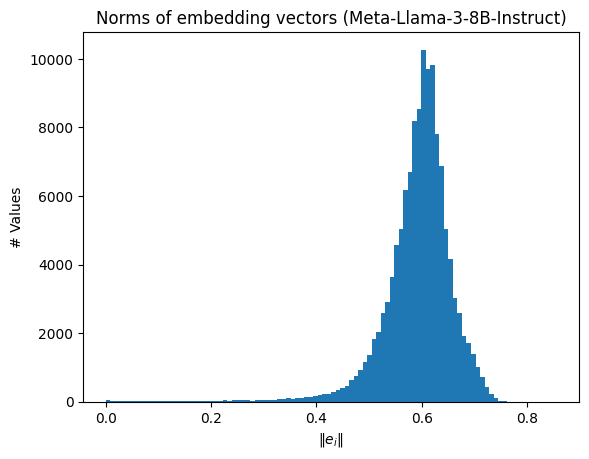

In [5]:
norms = torch.norm(embed_matrix, dim=-1).to("cpu")
plt.figure()
plt.hist(norms, bins=100)
plt.title("Norms of embedding vectors (Meta-Llama-3-8B-Instruct)")
plt.xlabel("$\Vert e_i\Vert$")
plt.ylabel("# Values")
plt.show()
plt.close()

In [6]:
def cosine_histogram_streaming(
    X_norm,           # (N, n), already normalized
    bins=200,
    block=1024,
    min_val=-1.0,
    max_val=1.0,
):
    device = X_norm.device
    hist_cpu = torch.zeros(bins, device="cpu")
    N = X_norm.size(0)
    for i in range(0, N, block):
        Xi = X_norm[i:i+block]

        for j in range(i + block, N, block):
            Xj = X_norm[j:j+block]

            sims = Xi @ Xj.T   # (bi, bj), temporary only

            # bin + accumulate
            hist_cpu += torch.histc(
                sims.float().cpu(),
                bins=bins,
                min=min_val,
                max=max_val
            )

        # handle diagonal block (upper triangle only)
        sims = Xi @ Xi.T
        iu = torch.triu_indices(
            sims.size(0),
            sims.size(1),
            offset=1,
            device=device
        )
        hist_cpu += torch.histc(
            sims[iu[0], iu[1]].float().cpu(),
            bins=bins,
            min=min_val,
            max=max_val
        )

    return hist_cpu

In [7]:
embed_matrix_norm = F.normalize(embed_matrix.to("cuda:1"), p=2, dim=1)
hist_cpu = cosine_histogram_streaming(embed_matrix_norm, bins=1000)

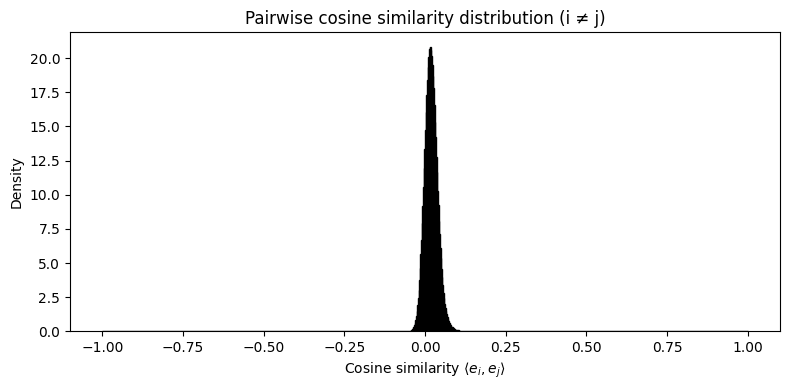

In [8]:
hist = hist_cpu.float()

bins = hist.numel()
min_val, max_val = -1.0, 1.0
bin_width = (max_val - min_val) / bins

# Normalize to a probability density
total_pairs = hist.sum()
pdf = hist / (total_pairs * bin_width)

# Bin centers
bin_edges = torch.linspace(min_val, max_val, bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(8, 4))
plt.bar(bin_centers.numpy(), pdf.numpy(), width=bin_width, align='center', edgecolor='k')
plt.xlabel(r"Cosine similarity $\langle e_i, e_j \rangle$")
plt.ylabel("Density")
plt.title("Pairwise cosine similarity distribution (i ≠ j)")
plt.tight_layout()
plt.show()
plt.close()

In [29]:
@torch.no_grad()
def streaming_convex_combination_norm_sq(
    embedding_iterator,
):
    """
    embedding_iterator: iterable yielding tensors of shape (batch_size, n)
    Assumes rows are approximately unit-norm.
    """

    sum_vec = None
    sum_norm_sq = 0.0
    N = 0

    for x in embedding_iterator:
        if sum_vec is None:
            sum_vec = torch.zeros(x.shape[1], device=x.device)

        sum_vec += x.sum(dim=0)
        sum_norm_sq += (x * x).sum().item()
        N += x.shape[0]

    sum_vec_norm_sq = sum_vec.dot(sum_vec).item()

    # sum_{i != j} <x_i, x_j>
    off_diag_sum = sum_vec_norm_sq - sum_norm_sq

    # E ||y||^2
    E_norm_sq = (2 * N + off_diag_sum) / (N * (N + 1))

    return {
        "N": N,
        "E_norm_sq": E_norm_sq,
        "E_norm": E_norm_sq ** 0.5,
        "avg_pairwise_dot": off_diag_sum / (N * (N - 1)),
    }

def embedding_iterator(embeddings, batch_size):
    for i in range(0, embeddings.shape[0], batch_size):
        yield embeddings[i:i+batch_size]

streaming_convex_combination_norm_sq(embedding_iterator(embed_matrix, 1024))

{'N': 128000,
 'E_norm_sq': 0.0065274276650548625,
 'E_norm': 0.08079249757901326,
 'avg_pairwise_dot': 0.006511904534837675}

In [ ]:
@torch.no_grad()
def estimate_E_norm_monte_carlo(
    embedding_iterator_factory,
    num_samples=100,
):
    """
    Estimates E[||y||] where y = sum_i w_i x_i, w ~ Dirichlet(1,...,1)

    embedding_iterator_factory: function that returns a fresh iterator
                                over batches of embeddings each time
    """

    norms = []

    for _ in range(num_samples):
        sum_vec = None
        sum_exp = 0.0

        for x in embedding_iterator_factory():

            if sum_vec is None:
                sum_vec = torch.zeros(x.shape[1], device=x.device, dtype=x.dtype)

            # sample exponential weights on the fly
            e = torch.empty(x.shape[0], device=x.device).exponential_(1.0)

            sum_vec += (e[:, None] * x).sum(dim=0)
            sum_exp += e.sum().item()

        y = sum_vec / sum_exp
        norms.append(y.norm().item())

    norms = torch.tensor(norms)
    return {
        "E_norm": norms.mean().item(),
        "std": norms.std(unbiased=True).item(),
        "stderr": norms.std(unbiased=True).item() / (len(norms) ** 0.5),
    }

iterator_factory = functools.partial(
    embedding_iterator,
    embed_matrix,
    batch_size=1024,
)

estimate_E_norm_monte_carlo(
    iterator_factory,
    num_samples=1000,
)

{'E_norm': 0.08072906732559204,
 'std': 5.4096592066343874e-05,
 'stderr': 1.7106844458264121e-06}

: 